A Python notebook to check specific unique entity ratio (UER) per type between two datasets.

## Libraries and Data

In [2]:
import numpy as np
import pandas as pd
import math
from collections import Counter
from EXPERIMENTS.evaluate_gold import load_and_merge_gold_data
from dataset_processing import generate_consistent_label_map, CLIRENER_LABELS_V1, calculate_advanced_metrics

#### Helper functions

In [3]:

def get_filtered_dataset_for_type(dataset, target_type, bio_label_list):
    """
    Creates a copy of the dataset where only the target_type 
    retains its BIO tags; all other entities are masked to 'O'.
    """
    filtered_data = []
    # Identify which IDs in the bio_label_list belong to our target_type
    target_ids = [i for i, name in enumerate(bio_label_list) 
                  if name == f"B-{target_type}" or name == f"I-{target_type}"]
    
    for row in dataset:
        new_tags = [tag if tag in target_ids else 0 for tag in row['ner_tags']]
        filtered_data.append({
            'tokens': row['tokens'],
            'ner_tags': new_tags
        })
    return filtered_data

#### Data

In [4]:



# --- 2. Setup and Loading ---
DATA_ID_1 = "P0L3/CliReNER_v_1_1_28_GOLD"
DATA_ID_2 = "P0L3/CliReNER_v_1_1_28_SILVER"

# actual_types: ['Ecosystem', 'Location', ...]
# bio_labels: ['O', 'B-Ecosystem', 'I-Ecosystem', ...]
actual_types = CLIRENER_LABELS_V1
bio_labels = list(generate_consistent_label_map(CLIRENER_LABELS_V1))

data_1 = load_and_merge_gold_data(DATA_ID_1)
data_2 = load_and_merge_gold_data(DATA_ID_2)

# Using the test splits as requested
gold_test = data_1[0]["test"]
silver_test = data_2[0]["test"]

--- Loading and Merging GOLD Dataset: P0L3/CliReNER_v_1_1_28_GOLD ---
Merged ['train', 'validation', 'test'] into a single dataset of size: 192
--- Loading and Merging GOLD Dataset: P0L3/CliReNER_v_1_1_28_SILVER ---
Merged ['train', 'validation', 'test'] into a single dataset of size: 1027


## Calc

In [5]:
# --- 3. Systematic Execution ---
all_type_results = []

for entity_type in actual_types:
    # Filter datasets to isolate this specific entity type
    gold_filtered = get_filtered_dataset_for_type(gold_test, entity_type, bio_labels)
    silver_filtered = get_filtered_dataset_for_type(silver_test, entity_type, bio_labels)
    
    # Run your advanced metrics function
    gold_metrics = calculate_advanced_metrics(gold_filtered, bio_labels)
    silver_metrics = calculate_advanced_metrics(silver_filtered, bio_labels)
    
    if gold_metrics and silver_metrics:
        # We also need to calculate the "Novelty Gap" manually 
        # because the function looks at datasets in isolation.
        
        def get_vocab(dataset_split, target_type, label_names):
            # Helper to get the set of unique lowercased strings for overlap check
            vocab = set()
            for row in dataset_split:
                tokens, tags = row['tokens'], row['ner_tags']
                for i, tid in enumerate(tags):
                    if label_names[tid] == f"B-{target_type}":
                        j = i + 1
                        while j < len(tags) and label_names[tags[j]] == f"I-{target_type}":
                            j += 1
                        vocab.add(" ".join(tokens[i:j]).lower())
            return vocab

        g_vocab = get_vocab(gold_test, entity_type, bio_labels)
        s_vocab = get_vocab(silver_test, entity_type, bio_labels)
        
        overlap = len(g_vocab.intersection(s_vocab))
        novelty_rate = (1 - (overlap / len(g_vocab))) * 100 if g_vocab else 0

        all_type_results.append({
            "Type": entity_type,
            "Gold_Count": gold_metrics["Total Entities"],
            "Silver_Count": silver_metrics["Total Entities"],
            "Gold_TTR (UER)": round(gold_metrics["Entity TTR (0-1)"], 3),
            "Silver_TTR (UER)": round(silver_metrics["Entity TTR (0-1)"], 3),
            "TTR_Diff": round(gold_metrics["Entity TTR (0-1)"] - silver_metrics["Entity TTR (0-1)"], 3),
            "Novelty_Rate (%)": round(novelty_rate, 1),
            "Gold_Avg_Len": round(gold_metrics["Avg Span Len"], 2),
            "Gold_Clumping": round(gold_metrics["Clumping (Adj) %"], 1)
        })

# --- 4. Final Comparison Table ---
df = pd.DataFrame(all_type_results).sort_values("Novelty_Rate (%)", ascending=False)

print("\nCross-Type Comparison using Advanced Metrics")
print("=" * 100)
print(df.to_string(index=False))

# Outlier Detection for Ecosystem
eco_row = df[df["Type"] == "Ecosystem"]
avg_novelty = df["Novelty_Rate (%)"].mean()
avg_ttr_diff = df["TTR_Diff"].mean()

print("\n--- Diagnostic Findings ---")
if not eco_row.empty:
    e_nov = eco_row["Novelty_Rate (%)"].values[0]
    e_diff = eco_row["TTR_Diff"].values[0]
    
    print(f"Ecosystem Novelty Rate: {e_nov}% (Dataset Avg: {avg_novelty:.1f}%)")
    print(f"Ecosystem TTR Increase: {e_diff} (Dataset Avg: {avg_ttr_diff:.3f})")
    
    if e_nov > avg_novelty + 15:
        print(">> Ecosystem is an outlier in NOVELTY: The model is seeing words it never practiced.")
    if e_diff > 0.1:
        print(">> Ecosystem is an outlier in DIVERSITY: The silver set is too repetitive compared to gold.")


Cross-Type Comparison using Advanced Metrics
                     Type  Gold_Count  Silver_Count  Gold_TTR (UER)  Silver_TTR (UER)  TTR_Diff  Novelty_Rate (%)  Gold_Avg_Len  Gold_Clumping
       Natural Phenomenon          80            86           0.938             0.930     0.007              94.7          1.85           18.8
                   Policy          73            74           0.973             0.878     0.094              94.4          2.44           32.9
      Physical Phenomenon          72           278           0.944             0.665     0.279              91.2          1.65           15.3
        Physical Artefact          66            52           0.924             0.846     0.078              90.2          1.55           21.2
     Geographical Feature          57            89           0.965             0.888     0.077              89.1          1.86           12.3
  Mathematical Expression          45            62           0.867             0.903    -0.037 

In [ ]:

GOLD_FILE = "EXPERIMENTS/VISUALS/clirener_GOLDagg_aggregated_mean_std.csv" # "clirener_aggregated_mean_std.csv"
SILVER_FILE = "EXPERIMENTS/VISUALS/clirener_silver_aggregated_mean_std.csv"

# Choose the metric for gap analysis:
# options: strict_f1_mean, exact_f1_mean, partial_f1_mean, ent_type_f1_mean
TARGET_METRIC = "strict_f1_mean" 

# --- Normalization Map (Unifies names between both files) ---
NAME_NORMALIZATION = {
    "GLiNER_Medium": "GLiNER: Medium v2.5",
    "GLiNER_Small": "GLiNER: Small v2.5",
    "INDUS SDE Base": "INDUS SDE v0.2"
}


print(f"Analyzing Generalization Gap: {SILVER_FILE} -> {GOLD_FILE}")
print(f"Metric: {TARGET_METRIC}\n")

try:
    df_gold = pd.read_csv(GOLD_FILE)
    df_silver = pd.read_csv(SILVER_FILE)
except FileNotFoundError as e:
    print(f"Error: {e}")

# --- STEP 0: UNIFY NAMES ---
df_gold['model_display_name'] = df_gold['model_display_name'].replace(NAME_NORMALIZATION)
df_silver['model_display_name'] = df_silver['model_display_name'].replace(NAME_NORMALIZATION)

# Standardize metrics (ensure silver 'type_f1' matches gold 'ent_type_f1' if necessary)
# This logic handles the naming discrepancy between the two projects
if TARGET_METRIC == "ent_type_f1_mean" and "type_f1_mean" in df_silver.columns:
    silver_metric = "type_f1_mean"
elif TARGET_METRIC == "type_f1_mean" and "ent_type_f1_mean" in df_gold.columns:
    # If user asked for type_f1 but gold uses ent_type_f1
    df_gold = df_gold.rename(columns={"ent_type_f1_mean": "type_f1_mean"})
    silver_metric = TARGET_METRIC
else:
    silver_metric = TARGET_METRIC

# --- STEP 1: MERGE DATASETS ---
# Merge on model and tag to compare directly
merged = pd.merge(
    df_gold[['model_display_name', 'tag', TARGET_METRIC]],
    df_silver[['model_display_name', 'tag', silver_metric]],
    on=['model_display_name', 'tag'],
    suffixes=('_gold', '_silver')
)

if merged.empty:
    print("Error: No overlapping models/tags found between Gold and Silver files.")


# --- STEP 2: CALCULATE GAPS ---

# 1. Calculate Absolute Gap
merged['abs_gap'] = merged[f'{silver_metric}_silver'] - merged[f'{TARGET_METRIC}_gold']

# 2. Calculate Percentage Change safely
# We only calculate % if Silver > 0; otherwise, we set it to NaN so it doesn't spoil the mean
merged['percent_change'] = np.where(
    merged[f'{silver_metric}_silver'] > 0, 
    (merged['abs_gap'] / merged[f'{silver_metric}_silver']) * 100, 
    np.nan
)

# Now, when you do .mean(), Pandas will ignore the NaN values 
# (skipna=True is the default), giving you the average of the models that actually had scores.

# =================================================================
# ANALYSIS A: Gap by Entity Class (Which tags are most inconsistent?)
# =================================================================
print(f"{'='*70}")
print(f"GENERALIZATION GAP BY CLASS (Average across all models)")
print(f"{'='*70}")

tag_gap = merged.groupby('tag')[['abs_gap', 'percent_change']].mean().reset_index()
tag_gap = tag_gap.sort_values('abs_gap', ascending=False)

print(tag_gap.to_string(index=False, formatters={'abs_gap': '{:,.4f}'.format, 'percent_change': '{:,.2f}%'.format}))
tag_gap.rename(columns={"tag":"Type"}, inplace=True)

Analyzing Generalization Gap: EXPERIMENTS/VISUALS/clirener_silver_aggregated_mean_std.csv -> EXPERIMENTS/VISUALS/clirener_GOLDagg_aggregated_mean_std.csv
Metric: strict_f1_mean

GENERALIZATION GAP BY CLASS (Average across all models)
                      tag abs_gap percent_change
Meteorological Phenomenon  0.2583         41.58%
                   Person  0.2399         34.07%
                Ecosystem  0.2309         28.70%
                    Asset  0.2231         70.09%
      Physical Phenomenon  0.1683         32.33%
                   Policy  0.1658         52.63%
             Organization  0.1337         18.59%
    Intellectual Artefact  0.0868         15.78%
                   Method  0.0849         12.44%
                    Other  0.0642         16.82%
         Measuring Device  0.0536          7.13%
                  Disease  0.0514          3.82%
                 Chemical  0.0419          4.65%
                Satellite  0.0330          9.72%
       Natural Phenomenon  0.02

In [19]:
df_withgap = pd.merge(tag_gap, df, on="Type")

In [23]:
df_withgap

,Type,abs_gap,percent_change,Gold_Count,Silver_Count,Gold_TTR (UER),Silver_TTR (UER),TTR_Diff,Novelty_Rate (%),Gold_Avg_Len,Gold_Clumping
0,Meteorological Phenomenon,0.258318,41.583077,81,255,0.728,0.427,0.301,83.1,1.69,18.5
1,Person,0.239907,34.066042,135,191,0.630,0.654,-0.025,87.1,3.67,25.2
2,Ecosystem,0.230868,28.704264,56,89,0.661,0.449,0.211,64.9,1.71,16.1
3,Asset,0.223056,70.092414,79,50,0.797,0.760,0.037,85.7,1.34,25.3
4,Physical Phenomenon,0.168330,32.334104,72,278,0.944,0.665,0.279,91.2,1.65,15.3
5,Policy,0.165756,52.625677,73,74,0.973,0.878,0.094,94.4,2.44,32.9
6,Organization,0.133703,18.589307,49,125,0.816,0.824,-0.008,70.0,3.27,16.3
7,Intellectual Artefact,0.086816,15.776252,203,416,0.650,0.608,0.042,75.0,1.67,18.2
8,Method,0.084913,12.442289,107,536,0.907,0.739,0.168,71.1,1.87,16.8
9,Other,0.064241,16.816314,113,860,0.903,0.801,0.101,74.5,1.33,11.5


Spearman Correlation with Performance Gap (abs_gap):
Gold_Count          0.319190
Gold_Avg_Len        0.260131
Novelty_Rate (%)    0.217843
Silver_Count        0.197754
Gold_Clumping       0.115490
TTR_Diff            0.084029
Gold_TTR (UER)     -0.081554
Silver_TTR (UER)   -0.125359
Name: abs_gap, dtype: float64


/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.py:948: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/p0l3/.local/lib/python3.10/site-packages/seaborn/_base.

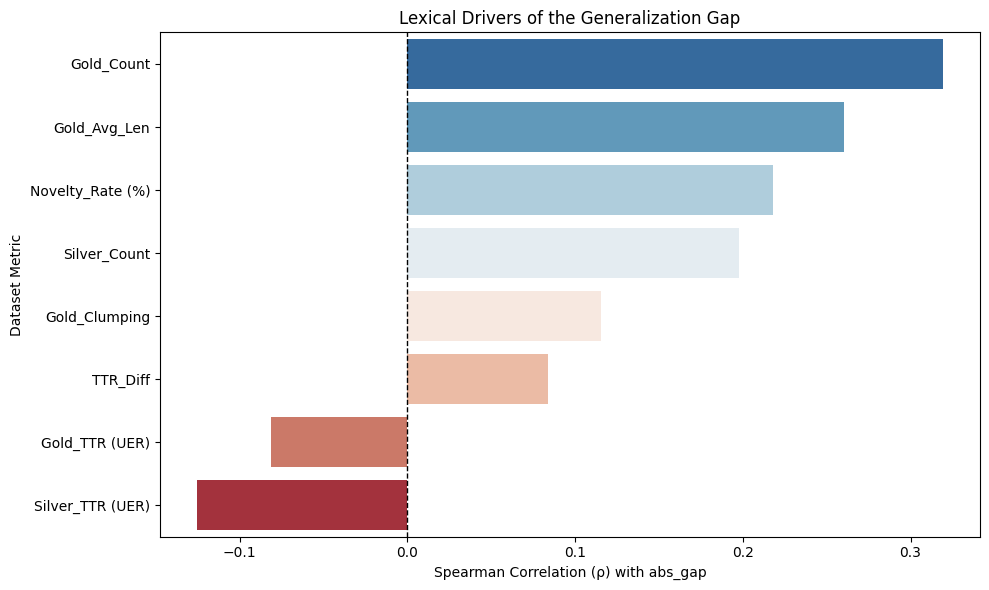

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate Spearman correlation, ensuring we only look at numeric columns
# We use abs() on correlations at the end if we want to see 'magnitude', 
# but raw values are better for knowing the 'direction' of the effect.
correlations = df_withgap.corr(method='spearman', numeric_only=True)['abs_gap'].sort_values(ascending=False)

# 2. Remove 'abs_gap' and 'percent_change' from the results so we only see external predictors
predictors = correlations.drop(['abs_gap', 'percent_change'], errors='ignore')

print("Spearman Correlation with Performance Gap (abs_gap):")
print(predictors)

# 3. Visualization
plt.figure(figsize=(10, 6))
sns.barplot(x=predictors.values, y=predictors.index, hue=predictors.index, palette='RdBu_r', legend=False)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.title("Lexical Drivers of the Generalization Gap")
plt.xlabel("Spearman Correlation (ρ) with abs_gap")
plt.ylabel("Dataset Metric")
plt.tight_layout()
plt.show()